In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */
.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */
.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */
.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */
.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */
.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */
.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))


In [5]:
# GPU 활성화 끄기
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 1. 기존의 프로그램 방식

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [9]:
input_data = int(input('섭씨온도는 '))
print('화씨온도는 ', celsius_to_faherenheit(input_data))

섭씨온도는 0
화씨온도는  32.0


# 2. 머신러닝 / 딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기(학습데이터셋과 검증데이터셋으로)
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)

## 2.1 노이즈가 없는 데이터로 실습

In [10]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [11]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수==종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [13]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종속변수는 ', scaled_data_F)

독립변수는  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종속변수는  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.7

In [14]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 개수
               input_shape=(1,) # 입력(독립)변수의 shape
               ))
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


- 회귀분석 오차함수 : 
    MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE단점이 어느정도 해소. 덜 민감), MEA(절대값평균)

In [16]:
# 4. 모델 학습과정 설정
model.compile(
    loss='mse', # 손실함수
    optimizer='rmsprop', # 옵티마이저
    metrics=['mae']  # 평가지표
             ) 
# loss(오차, 손실함수)는 모델 학습 중 최적화할 대상
# metrics : 평가지표

In [18]:
# 학습 전 예측
model.predict(np.array([[0], [0.01]]))

1/1 [==============================] - 0s 166ms/step


array([[ 0.        ],
       [-0.01531455]], dtype=float32)

In [20]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel에 w(기울기), bias에 b이 있음
# from tensorflow.keras.models import save_model
# save_model(model, 'model/before_learning.h5')

In [21]:
# 모델 학습시키기 - 1번만 실행
hist = model.fit(
    scaled_data_C, # 독립변수
    scaled_data_F, # 타겟변수(종속)
    epochs=1000,  # 학습횟수
    verbose=2 # 학습시 출력여부
)

Epoch 1/1000
4/4 - 1s - loss: 4.7824 - mae: 1.9645 - 650ms/epoch - 162ms/step
Epoch 2/1000
4/4 - 0s - loss: 4.7323 - mae: 1.9528 - 11ms/epoch - 3ms/step
Epoch 3/1000
4/4 - 0s - loss: 4.6993 - mae: 1.9451 - 11ms/epoch - 3ms/step
Epoch 4/1000
4/4 - 0s - loss: 4.6694 - mae: 1.9381 - 11ms/epoch - 3ms/step
Epoch 5/1000
4/4 - 0s - loss: 4.6404 - mae: 1.9311 - 8ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 4.6146 - mae: 1.9251 - 7ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 4.5877 - mae: 1.9187 - 7ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 4.5637 - mae: 1.9130 - 10ms/epoch - 3ms/step
Epoch 9/1000
4/4 - 0s - loss: 4.5393 - mae: 1.9071 - 6ms/epoch - 1ms/step
Epoch 10/1000
4/4 - 0s - loss: 4.5175 - mae: 1.9018 - 8ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 4.4934 - mae: 1.8961 - 10ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 4.4677 - mae: 1.8899 - 6ms/epoch - 1ms/step
Epoch 13/1000
4/4 - 0s - loss: 4.4448 - mae: 1.8843 - 7ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s - 

Epoch 110/1000
4/4 - 0s - loss: 2.4335 - mae: 1.3226 - 12ms/epoch - 3ms/step
Epoch 111/1000
4/4 - 0s - loss: 2.4142 - mae: 1.3165 - 9ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 2.3973 - mae: 1.3111 - 11ms/epoch - 3ms/step
Epoch 113/1000
4/4 - 0s - loss: 2.3813 - mae: 1.3060 - 7ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 2.3664 - mae: 1.3011 - 11ms/epoch - 3ms/step
Epoch 115/1000
4/4 - 0s - loss: 2.3502 - mae: 1.2959 - 11ms/epoch - 3ms/step
Epoch 116/1000
4/4 - 0s - loss: 2.3351 - mae: 1.2912 - 10ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 2.3192 - mae: 1.2860 - 6ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 2.3023 - mae: 1.2805 - 9ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 2.2867 - mae: 1.2756 - 9ms/epoch - 2ms/step
Epoch 120/1000
4/4 - 0s - loss: 2.2691 - mae: 1.2700 - 8ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 2.2503 - mae: 1.2638 - 9ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 2.2339 - mae: 1.2585 - 7ms/epoch - 2ms/step
Epoch 1

Epoch 218/1000
4/4 - 0s - loss: 1.0022 - mae: 0.8175 - 8ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.9926 - mae: 0.8136 - 8ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.9836 - mae: 0.8100 - 9ms/epoch - 2ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.9725 - mae: 0.8055 - 9ms/epoch - 2ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.9629 - mae: 0.8015 - 7ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.9550 - mae: 0.7982 - 7ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.9464 - mae: 0.7947 - 7ms/epoch - 2ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.9365 - mae: 0.7908 - 9ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.9288 - mae: 0.7876 - 9ms/epoch - 2ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.9204 - mae: 0.7842 - 11ms/epoch - 3ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.9101 - mae: 0.7797 - 9ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.9009 - mae: 0.7759 - 10ms/epoch - 3ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.8923 - mae: 0.7724 - 9ms/epoch - 2ms/step
Epoch 231/

Epoch 326/1000
4/4 - 0s - loss: 0.3776 - mae: 0.5285 - 8ms/epoch - 2ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.3751 - mae: 0.5271 - 7ms/epoch - 2ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.3730 - mae: 0.5258 - 9ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.3706 - mae: 0.5242 - 10ms/epoch - 2ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.3679 - mae: 0.5227 - 10ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.3664 - mae: 0.5219 - 7ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.3639 - mae: 0.5201 - 11ms/epoch - 3ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.3616 - mae: 0.5187 - 8ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.3598 - mae: 0.5175 - 9ms/epoch - 2ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.3580 - mae: 0.5163 - 10ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.3565 - mae: 0.5153 - 7ms/epoch - 2ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.3549 - mae: 0.5143 - 8ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.3531 - mae: 0.5131 - 10ms/epoch - 2ms/step
Epoch 3

Epoch 434/1000
4/4 - 0s - loss: 0.2453 - mae: 0.4281 - 9ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.2445 - mae: 0.4274 - 5ms/epoch - 1ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.2434 - mae: 0.4264 - 10ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.2427 - mae: 0.4256 - 8ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.2420 - mae: 0.4251 - 5ms/epoch - 1ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.2413 - mae: 0.4245 - 6ms/epoch - 1ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.2406 - mae: 0.4240 - 7ms/epoch - 2ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.2395 - mae: 0.4230 - 6ms/epoch - 1ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.2387 - mae: 0.4223 - 10ms/epoch - 3ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.2378 - mae: 0.4215 - 8ms/epoch - 2ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.2370 - mae: 0.4208 - 11ms/epoch - 3ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.2360 - mae: 0.4199 - 8ms/epoch - 2ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.2352 - mae: 0.4191 - 7ms/epoch - 2ms/step
Epoch 447

Epoch 542/1000
4/4 - 0s - loss: 0.1529 - mae: 0.3377 - 9ms/epoch - 2ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.1522 - mae: 0.3371 - 9ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.1515 - mae: 0.3364 - 6ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.1510 - mae: 0.3357 - 8ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.1502 - mae: 0.3350 - 9ms/epoch - 2ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.1494 - mae: 0.3340 - 5ms/epoch - 1ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.1487 - mae: 0.3333 - 6ms/epoch - 2ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.1480 - mae: 0.3324 - 10ms/epoch - 3ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.1470 - mae: 0.3314 - 8ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.1463 - mae: 0.3305 - 8ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.1455 - mae: 0.3295 - 7ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.1449 - mae: 0.3288 - 10ms/epoch - 2ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.1443 - mae: 0.3280 - 9ms/epoch - 2ms/step
Epoch 555/

Epoch 650/1000
4/4 - 0s - loss: 0.0849 - mae: 0.2516 - 10ms/epoch - 3ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0843 - mae: 0.2506 - 9ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.0837 - mae: 0.2497 - 10ms/epoch - 2ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.0833 - mae: 0.2491 - 8ms/epoch - 2ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.0826 - mae: 0.2482 - 12ms/epoch - 3ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.0820 - mae: 0.2472 - 8ms/epoch - 2ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.0816 - mae: 0.2465 - 8ms/epoch - 2ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.0809 - mae: 0.2456 - 11ms/epoch - 3ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.0803 - mae: 0.2447 - 9ms/epoch - 2ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.0798 - mae: 0.2439 - 9ms/epoch - 2ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.0792 - mae: 0.2431 - 8ms/epoch - 2ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.0787 - mae: 0.2422 - 9ms/epoch - 2ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.0781 - mae: 0.2413 - 8ms/epoch - 2ms/step
Epoch 66

Epoch 758/1000
4/4 - 0s - loss: 0.0346 - mae: 0.1606 - 8ms/epoch - 2ms/step
Epoch 759/1000
4/4 - 0s - loss: 0.0342 - mae: 0.1597 - 8ms/epoch - 2ms/step
Epoch 760/1000
4/4 - 0s - loss: 0.0338 - mae: 0.1588 - 10ms/epoch - 3ms/step
Epoch 761/1000
4/4 - 0s - loss: 0.0335 - mae: 0.1580 - 10ms/epoch - 2ms/step
Epoch 762/1000
4/4 - 0s - loss: 0.0331 - mae: 0.1571 - 10ms/epoch - 2ms/step
Epoch 763/1000
4/4 - 0s - loss: 0.0327 - mae: 0.1563 - 9ms/epoch - 2ms/step
Epoch 764/1000
4/4 - 0s - loss: 0.0323 - mae: 0.1553 - 8ms/epoch - 2ms/step
Epoch 765/1000
4/4 - 0s - loss: 0.0320 - mae: 0.1545 - 10ms/epoch - 3ms/step
Epoch 766/1000
4/4 - 0s - loss: 0.0316 - mae: 0.1535 - 11ms/epoch - 3ms/step
Epoch 767/1000
4/4 - 0s - loss: 0.0312 - mae: 0.1526 - 9ms/epoch - 2ms/step
Epoch 768/1000
4/4 - 0s - loss: 0.0310 - mae: 0.1520 - 10ms/epoch - 2ms/step
Epoch 769/1000
4/4 - 0s - loss: 0.0307 - mae: 0.1513 - 10ms/epoch - 2ms/step
Epoch 770/1000
4/4 - 0s - loss: 0.0304 - mae: 0.1506 - 10ms/epoch - 2ms/step
Epoc

Epoch 866/1000
4/4 - 0s - loss: 0.0068 - mae: 0.0710 - 8ms/epoch - 2ms/step
Epoch 867/1000
4/4 - 0s - loss: 0.0066 - mae: 0.0700 - 8ms/epoch - 2ms/step
Epoch 868/1000
4/4 - 0s - loss: 0.0065 - mae: 0.0692 - 8ms/epoch - 2ms/step
Epoch 869/1000
4/4 - 0s - loss: 0.0063 - mae: 0.0684 - 7ms/epoch - 2ms/step
Epoch 870/1000
4/4 - 0s - loss: 0.0062 - mae: 0.0677 - 6ms/epoch - 1ms/step
Epoch 871/1000
4/4 - 0s - loss: 0.0060 - mae: 0.0669 - 8ms/epoch - 2ms/step
Epoch 872/1000
4/4 - 0s - loss: 0.0058 - mae: 0.0660 - 7ms/epoch - 2ms/step
Epoch 873/1000
4/4 - 0s - loss: 0.0057 - mae: 0.0652 - 8ms/epoch - 2ms/step
Epoch 874/1000
4/4 - 0s - loss: 0.0056 - mae: 0.0645 - 7ms/epoch - 2ms/step
Epoch 875/1000
4/4 - 0s - loss: 0.0055 - mae: 0.0637 - 6ms/epoch - 2ms/step
Epoch 876/1000
4/4 - 0s - loss: 0.0053 - mae: 0.0632 - 11ms/epoch - 3ms/step
Epoch 877/1000
4/4 - 0s - loss: 0.0052 - mae: 0.0624 - 7ms/epoch - 2ms/step
Epoch 878/1000
4/4 - 0s - loss: 0.0051 - mae: 0.0617 - 6ms/epoch - 2ms/step
Epoch 879/1

Epoch 971/1000
4/4 - 0s - loss: 4.6990e-07 - mae: 6.7043e-04 - 6ms/epoch - 2ms/step
Epoch 972/1000
4/4 - 0s - loss: 2.6649e-07 - mae: 5.0747e-04 - 6ms/epoch - 2ms/step
Epoch 973/1000
4/4 - 0s - loss: 1.7119e-07 - mae: 3.8610e-04 - 6ms/epoch - 2ms/step
Epoch 974/1000
4/4 - 0s - loss: 1.4545e-06 - mae: 0.0012 - 8ms/epoch - 2ms/step
Epoch 975/1000
4/4 - 0s - loss: 8.1643e-08 - mae: 2.7103e-04 - 6ms/epoch - 2ms/step
Epoch 976/1000
4/4 - 0s - loss: 3.7411e-07 - mae: 5.8563e-04 - 7ms/epoch - 2ms/step
Epoch 977/1000
4/4 - 0s - loss: 1.3535e-06 - mae: 0.0011 - 9ms/epoch - 2ms/step
Epoch 978/1000
4/4 - 0s - loss: 8.5073e-08 - mae: 2.8545e-04 - 6ms/epoch - 1ms/step
Epoch 979/1000
4/4 - 0s - loss: 3.6205e-07 - mae: 5.7717e-04 - 7ms/epoch - 2ms/step
Epoch 980/1000
4/4 - 0s - loss: 4.9587e-07 - mae: 6.7615e-04 - 7ms/epoch - 2ms/step
Epoch 981/1000
4/4 - 0s - loss: 1.3367e-06 - mae: 0.0011 - 6ms/epoch - 1ms/step
Epoch 982/1000
4/4 - 0s - loss: 2.1199e-07 - mae: 4.4894e-04 - 6ms/epoch - 2ms/step
Epoc

In [22]:
hist.history.keys()

dict_keys(['loss', 'mae'])

Text(0, 0.5, 'error value')

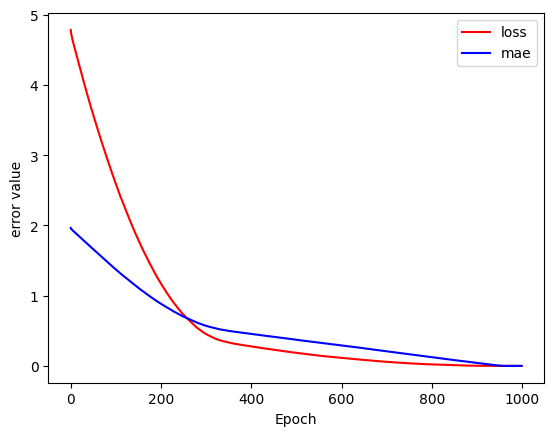

In [24]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [25]:
# 모델 사용
model.predict(np.array([ [0], [0.01], [0.02] ]) )

1/1 [==============================] - 0s 26ms/step


array([[0.32078943],
       [0.33880216],
       [0.3568149 ]], dtype=float32)

In [26]:
model.save('model/after_learning.h5')